# 4 · Vortex lattice method

Horseshoe vortices on the quarter-chord line of each panel, tangency at the three-quarter
chord, induced drag in the Trefftz plane. See [docs/vortex_lattice_3d.md](../docs/vortex_lattice_3d.md).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from aero import plotting as P

P.use_style()
DEG = np.pi / 180
from aero.vortex_lattice_3d import Wing, solve_vlm, solve_lifting_line

In [2]:
for ar in (4, 8, 20):
    s = solve_vlm(Wing.elliptic(ar), 5 * DEG, 40, 6)
    print(f"Elliptic AR {ar:2d}: CL_alpha = {s.CL / (5 * DEG):.3f}/rad "
          f"(LL {2 * np.pi / (1 + 2 / ar):.3f}),  e = {s.span_efficiency:.4f}")

Elliptic AR  4: CL_alpha = 3.728/rad (LL 4.189),  e = 0.9982
Elliptic AR  8: CL_alpha = 4.783/rad (LL 5.027),  e = 0.9992
Elliptic AR 20: CL_alpha = 5.634/rad (LL 5.712),  e = 1.0003


CL = 0.329, CDi = 0.00579, e = 0.993, Cm (root c/4) = -0.269


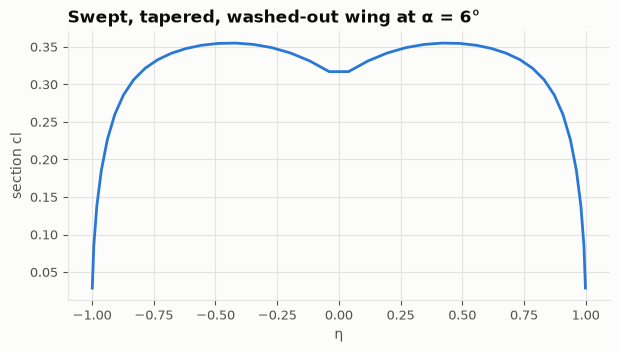

In [3]:
w = Wing.tapered(6, 0.4, sweep=35 * DEG, twist=lambda eta: -3 * DEG * eta)
s = solve_vlm(w, 6 * DEG, 40, 8)
print(f"CL = {s.CL:.3f}, CDi = {s.CDi:.5f}, e = {s.span_efficiency:.3f}, Cm (root c/4) = {s.Cm:.3f}")
eta = 2 * s.y_mid / w.span
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(eta, s.cl_span, color=P.SERIES[0])
ax.set_xlabel("η"); ax.set_ylabel("section cl")
ax.set_title("Swept, tapered, washed-out wing at α = 6°");